In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_colwidth', 200)

In [2]:
url = "https://raw.githubusercontent.com/AwalDinz/analisis-sentimen-wisata-banda-aceh/main/dataset/dataset_preprocessing_final.csv"

df = pd.read_csv(url)

print("Jumlah data :", len(df))
print("Jumlah kolom :", len(df.columns))

df.head()

Jumlah data : 2582
Jumlah kolom : 8


,title,text,stars,publishedAtDate,likesCount,platform,tokens,text_preprocessed
0,Masjid Raya Baiturrahman,masjid raya baiturrahman aceh dibangun pada masa kesultanan aceh sekitar tahun oleh sultan iskandar muda ada juga versi yang menyebutkan pembangunannya lebih awal lagi simbol perlawanan saat belan...,5.0,12/02/2026 11:32,0,Google Maps,"['masjid', 'raya', 'baiturrahman', 'aceh', 'bangun', 'masa', 'sultan', 'aceh', 'tahun', 'sultan', 'iskandar', 'muda', 'versi', 'sebut', 'bangun', 'lebih', 'awal', 'simbol', 'lawan', 'belanda', 'se...",masjid raya baiturrahman aceh bangun masa sultan aceh tahun sultan iskandar muda versi sebut bangun lebih awal simbol lawan belanda serang aceh tahun masjid sempat bakar lawan rakyat aceh luar bia...
1,Masjid Raya Baiturrahman,masjid penuh sejarah bagi masyarakat terutama di banda aceh alhamdulillah saya dari palembang bisa berkunjung dan sholat disini masjidnya bersih teratur tempat parkirnya dan tentu nyaman bagi peng...,5.0,15/01/2026 08:09,0,Google Maps,"['masjid', 'penuh', 'sejarah', 'masyarakat', 'utama', 'banda', 'aceh', 'alhamdulillah', 'palembang', 'kunjung', 'sholat', 'sini', 'masjid', 'bersih', 'atur', 'tempat', 'parkir', 'nyaman', 'unjung'...",masjid penuh sejarah masyarakat utama banda aceh alhamdulillah palembang kunjung sholat sini masjid bersih atur tempat parkir nyaman unjung lokasi jauh museum tsunami jalan museum masjid baiturrah...
2,Masjid Raya Baiturrahman,mashaallah diijinkan untuk berkunjung kesini saksi bisu tsunami alhamdulillah kesini di temenin sama orang aceh jadi ngerangkap sebagai guide mana aja yang boleh dan ga boleh jadi buat kamu wanita...,5.0,21/01/2026 01:30,1,Google Maps,"['mashaallah', 'diijinkan', 'kunjung', 'kesini', 'saksi', 'bisu', 'tsunami', 'alhamdulillah', 'kesini', 'temenin', 'sama', 'orang', 'aceh', 'jadi', 'ngerangkap', 'guide', 'mana', 'aja', 'ga', 'jad...",mashaallah diijinkan kunjung kesini saksi bisu tsunami alhamdulillah kesini temenin sama orang aceh jadi ngerangkap guide mana aja ga jadi buat kamu wanita kesini wajid guna rok pakai hijab
3,Masjid Raya Baiturrahman,tiada kata selain subhanallah ini masjid bagus dan megah banget ingat dulu pas kecil liat video pas tsunami aceh masjid ini paling kokoh halaman masjidnya juga rapih warga yang masuk disiplin ngga...,5.0,09/11/2025 18:43,0,Google Maps,"['tiada', 'kata', 'subhanallah', 'masjid', 'bagus', 'megah', 'banget', 'ingat', 'dulu', 'pas', 'kecil', 'liat', 'video', 'pas', 'tsunami', 'aceh', 'masjid', 'paling', 'kokoh', 'halaman', 'masjid',...",tiada kata subhanallah masjid bagus megah banget ingat dulu pas kecil liat video pas tsunami aceh masjid paling kokoh halaman masjid rapih warga masuk disiplin tuh pakai alas makan injak rumput ba...
4,Masjid Raya Baiturrahman,setiap kali ke aceh wajib kesini masjid ini bukan saja indah megah tapi punya banyak cerita terutama buat saya saat jadi relawan tsunami dulu dan banjir aceh saat ini adem rasanya tenang,5.0,22/01/2026 18:04,0,Google Maps,"['kali', 'aceh', 'wajib', 'kesini', 'masjid', 'bukan', 'indah', 'megah', 'punya', 'banyak', 'cerita', 'utama', 'buat', 'jadi', 'rawan', 'tsunami', 'dulu', 'banjir', 'aceh', 'adem', 'rasa', 'tenang']",kali aceh wajib kesini masjid bukan indah megah punya banyak cerita utama buat jadi rawan tsunami dulu banjir aceh adem rasa tenang


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2582 entries, 0 to 2581
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              2582 non-null   object 
 1   text               2582 non-null   object 
 2   stars              2256 non-null   float64
 3   publishedAtDate    2582 non-null   object 
 4   likesCount         2582 non-null   int64  
 5   platform           2582 non-null   object 
 6   tokens             2582 non-null   object 
 7   text_preprocessed  2581 non-null   object 
dtypes: float64(1), int64(1), object(6)
memory usage: 161.5+ KB


In [4]:
df.columns.tolist()

['title',
 'text',
 'stars',
 'publishedAtDate',
 'likesCount',
 'platform',
 'tokens',
 'text_preprocessed']

In [5]:
df["stars"].value_counts(dropna=False).sort_index()

,count
stars,
1.0,50
2.0,44
3.0,175
4.0,502
5.0,1485
NaN,326


Label Sentimen

In [6]:
df_label = df.copy()

def label_sentimen(star):
    if pd.isna(star):
        return np.nan
    elif star <= 2:
        return "Negatif"
    elif star == 3:
        return "Netral"
    else:
        return "Positif"

df_label["sentimen"] = df_label["stars"].apply(label_sentimen)

df_label[["stars","sentimen"]].head()

,stars,sentimen
0,5.0,Positif
1,5.0,Positif
2,5.0,Positif
3,5.0,Positif
4,5.0,Positif


In [7]:
df_label["sentimen"].value_counts(dropna=False)

,count
sentimen,
Positif,1987
NaN,326
Netral,175
Negatif,94


In [8]:
df_train = df_label[df_label["sentimen"].notna()].copy()

print(df_train.shape)

(2256, 9)


In [9]:
df_tiktok = df_label[df_label["sentimen"].isna()].copy()

print(df_tiktok.shape)

(326, 9)


In [10]:
df_train["sentimen"].value_counts()

,count
sentimen,
Positif,1987
Netral,175
Negatif,94


visualisasi distribusi sentimen

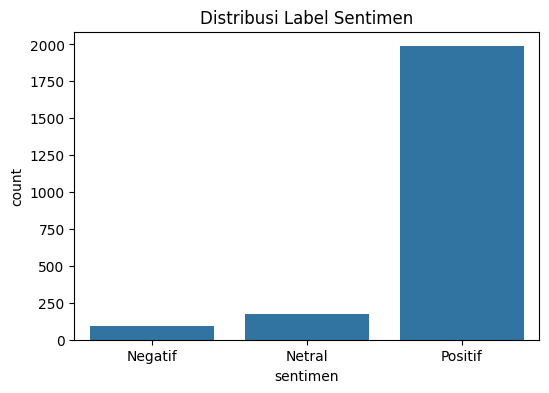

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df_train,
    x="sentimen",
    order=["Negatif","Netral","Positif"]
)

plt.title("Distribusi Label Sentimen")
plt.show()

Persiapan X dan y

In [12]:
X = df_train["text_preprocessed"]
y = df_train["sentimen"]

print(X.shape)
print(y.shape)

(2256,)
(2256,)


TF-IDF

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=5000
)

X_tfidf = tfidf.fit_transform(X)

print("Shape TF-IDF :", X_tfidf.shape)

ValueError: np.nan is an invalid document, expected byte or unicode string.

In [14]:
df_train["text_preprocessed"].isna().sum()

np.int64(1)

In [15]:
df_train[df_train["text_preprocessed"].isna()]

,title,text,stars,publishedAtDate,likesCount,platform,tokens,text_preprocessed,sentimen
378,Taman Sari Gunongan,ok,5.0,31/10/2023 11:25,0,Google Maps,[],NaN,Positif


In [16]:
df_train = df_train.dropna(subset=["text_preprocessed"])

print(df_train.shape)

(2255, 9)


ulang X dan y karena masih ada nilai kosong (NaN) yang lolos saat preprocessing.

In [17]:
X = df_train["text_preprocessed"]
y = df_train["sentimen"]

print(X.shape)
print(y.shape)

(2255,)
(2255,)


TF-IDF lagi

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=5000
)

X_tfidf = tfidf.fit_transform(X)

print("Shape TF-IDF :", X_tfidf.shape)

Shape TF-IDF : (2255, 5000)


Train-Test Split

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data Train :", X_train.shape)
print("Data Test  :", X_test.shape)

Data Train : (1804, 5000)
Data Test  : (451, 5000)


Training SVM

In [25]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',
    C=1,
    gamma='scale',
    class_weight='balanced'
)

svm_model.fit(X_train, y_train)

print("Training selesai")

Training selesai


Prediksi

In [27]:
y_pred = svm_model.predict(X_test)

print(y_pred[:10])

['Positif' 'Positif' 'Positif' 'Positif' 'Positif' 'Positif' 'Positif'
 'Positif' 'Positif' 'Positif']


Evaluasi Model

In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)
recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)
f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1-Score :", round(f1,4))

Accuracy : 0.8714
Precision: 0.8302
Recall   : 0.8714
F1-Score : 0.8274


Confusion Matrix

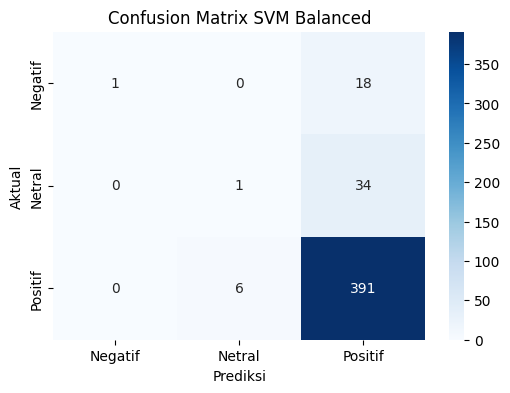

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negatif','Netral','Positif'],
    yticklabels=['Negatif','Netral','Positif']
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix SVM Balanced")
plt.show()

In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     Negatif       1.00      0.05      0.10        19
      Netral       0.14      0.03      0.05        35
     Positif       0.88      0.98      0.93       397

    accuracy                           0.87       451
   macro avg       0.68      0.36      0.36       451
weighted avg       0.83      0.87      0.83       451



In [34]:
df_train["sentimen"].value_counts(normalize=True)*100

,proportion
sentimen,
Positif,88.070953
Netral,7.760532
Negatif,4.168514


In [35]:
df_train["platform"].value_counts()

,count
platform,
Google Maps,2255


In [36]:
df_tiktok.shape

(326, 9)

In [37]:
df_tiktok[["title","platform","text_preprocessed"]].head()

,title,platform,text_preprocessed
2256,Masjid Raya Baiturrahman,TikTok,terimakasih atas vidio mahal sangat nikmat
2257,Masjid Raya Baiturrahman,TikTok,alhamdulillah sdh dpt masuk solat maghrib masjid baitulrahman yg lalu salam dr
2258,Masjid Raya Baiturrahman,TikTok,alhamdulillah
2259,Masjid Raya Baiturrahman,TikTok,masha allah
2260,Masjid Raya Baiturrahman,TikTok,allah ken sekali kunjung masjid raya baiturrahman banda aceh salam lampaseh


Ubah komentar TikTok menjadi TF-IDF

In [38]:
X_tiktok = tfidf.transform(df_tiktok["text_preprocessed"])

print(X_tiktok.shape)

(326, 5000)


Prediksi Sentimen TikTok

In [39]:
df_tiktok["prediksi_sentimen"] = svm_model.predict(X_tiktok)

df_tiktok[
    ["title","text_preprocessed","prediksi_sentimen"]
].head()

,title,text_preprocessed,prediksi_sentimen
2256,Masjid Raya Baiturrahman,terimakasih atas vidio mahal sangat nikmat,Positif
2257,Masjid Raya Baiturrahman,alhamdulillah sdh dpt masuk solat maghrib masjid baitulrahman yg lalu salam dr,Positif
2258,Masjid Raya Baiturrahman,alhamdulillah,Positif
2259,Masjid Raya Baiturrahman,masha allah,Positif
2260,Masjid Raya Baiturrahman,allah ken sekali kunjung masjid raya baiturrahman banda aceh salam lampaseh,Positif


Lihat Distribusi Sentimen TikTok

In [40]:
df_tiktok["prediksi_sentimen"].value_counts()

,count
prediksi_sentimen,
Positif,325
Netral,1


In [41]:
df_tiktok["prediksi_sentimen"].value_counts(normalize=True)*100

,proportion
prediksi_sentimen,
Positif,99.693252
Netral,0.306748


Visualisasi Sentimen TikTok

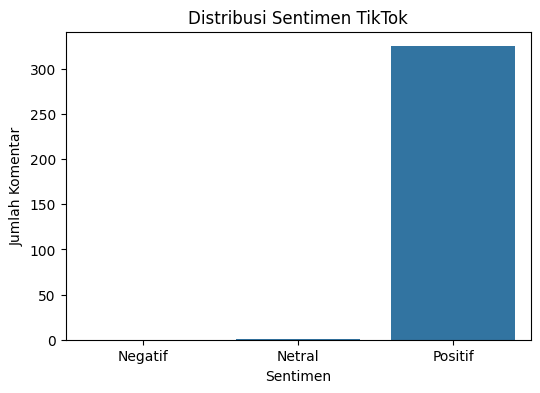

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(
    data=df_tiktok,
    x="prediksi_sentimen",
    order=["Negatif","Netral","Positif"]
)

plt.title("Distribusi Sentimen TikTok")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Komentar")
plt.show()

Analisis sentimen per destinasi

In [43]:
sentimen_destinasi = pd.crosstab(
    df_tiktok["title"],
    df_tiktok["prediksi_sentimen"]
)

sentimen_destinasi

prediksi_sentimen,Netral,Positif
title,,
Masjid Raya Baiturrahman,1,98
Museum PLTD Apung,0,43
Museum Tsunami Aceh,0,35
Pantai Lampuuk,0,99
Pantai Ulee Lheue,0,50


Urutkan destinasi dengan komentar terbanyak

In [44]:
df_tiktok["title"].value_counts()

,count
title,
Masjid Raya Baiturrahman,99
Pantai Lampuuk,99
Pantai Ulee Lheue,50
Museum PLTD Apung,43
Museum Tsunami Aceh,35


Cari jumlah sentimen per destinasi

In [45]:
hasil_destinasi = df_tiktok.groupby(
    ["title","prediksi_sentimen"]
).size().unstack(fill_value=0)

hasil_destinasi["total"] = hasil_destinasi.sum(axis=1)

hasil_destinasi.sort_values(
    "total",
    ascending=False
)

prediksi_sentimen,Netral,Positif,total
title,,,
Masjid Raya Baiturrahman,1,98,99
Pantai Lampuuk,0,99,99
Pantai Ulee Lheue,0,50,50
Museum PLTD Apung,0,43,43
Museum Tsunami Aceh,0,35,35


In [46]:
df_tiktok.to_csv(
    "hasil_prediksi_tiktok.csv",
    index=False,
    encoding="utf-8-sig"
)

print("File berhasil disimpan")

File berhasil disimpan


**Top 5 Destinasi Berdasarkan Jumlah Komentar TikTok**

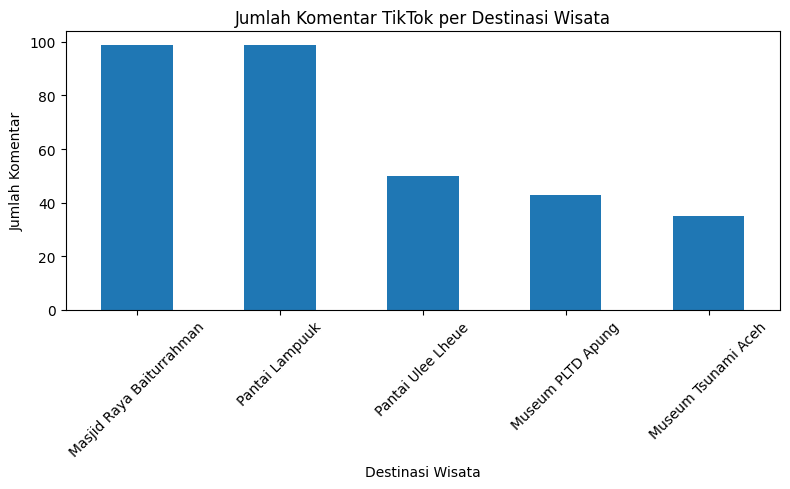

In [47]:
import matplotlib.pyplot as plt

top_destinasi = df_tiktok["title"].value_counts()

plt.figure(figsize=(8,5))

top_destinasi.plot(kind="bar")

plt.title("Jumlah Komentar TikTok per Destinasi Wisata")
plt.xlabel("Destinasi Wisata")
plt.ylabel("Jumlah Komentar")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

**Sentimen per Destinasi**

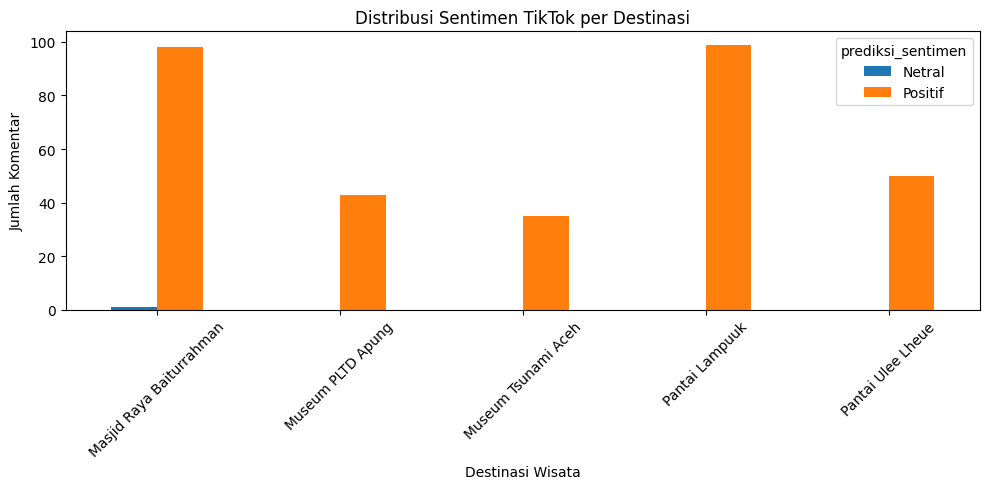

In [48]:
import matplotlib.pyplot as plt

sentimen_destinasi.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Distribusi Sentimen TikTok per Destinasi")
plt.xlabel("Destinasi Wisata")
plt.ylabel("Jumlah Komentar")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [49]:
import os
os.path.exists("hasil_prediksi_tiktok.csv")

True

In [50]:
from google.colab import drive
drive.mount('/content/drive')

df_tiktok.to_csv(
    "/content/drive/MyDrive/SEMESTER 6/DATASET/hasil_prediksi_tiktok.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Berhasil disimpan")

Mounted at /content/drive
Berhasil disimpan
